# Utilities

In [92]:
### ---- START M.L. Specific Imports --- ###
from assignment1_data.assignment1_data.mnist_dataloader import create_dataloaders
import torch
import torch.nn as nn
import tensorflow as tf
from torch.optim import (
    SGD,
    AdamW
)
from torchvision import transforms
from torchvision.transforms import v2
### ---- END M.L. Specific Imports --- ###

### ---- START General Imports --- ###
import matplotlib.pyplot as PLT
import numpy as np
import os
### ---- End General Imports --- ###


### --- START Experimental Design Setings definition --- ###
#TODO Trasnform this eventually in a parser...
batch_size:int = 64
loc:str = r"/DataSets"
epochs:int = 30
width:list = [32**2, 24**2, 22**2, 20**2, 22**2, 24**2, 32**2]
hidd_activation:str = "LeakyReLU"
final_activation:str = "Tanh"

# Loading, data visualization and exploratory data analysis (if required)

### Loading the data

In [ ]:
noisy_train, noisy_test, noisy_val = create_dataloaders(data_loc=loc, batch_size=batch_size)
sampple_train, sample_test, sample_val = next(enumerate(noisy_train))[1][0], next(enumerate(noisy_test))[1][0], next(enumerate(noisy_val))[1][0]


# Informative statement 1
print("Three Data-Loaders were created\n" \
"noisy_train of type {} with length {} batches, having extreme point of (min: {} max: {}) and both, variance = {} and mean = {}\n" \
"noisy_test of type {} with length {} batches, having extreme point of (min: {} max: {}) and both, variance = {} and mean = {}\n" \
"noisy_val of type {} with length {} batches, having extreme point of (min: {} max: {}) and both, variance = {} and mean = {}:".format(
                                               type(noisy_train), len(noisy_train), torch.min(sampple_train), torch.max(sampple_train), torch.mean(sampple_train), torch.var(sampple_train),
                                               type(noisy_test), len(noisy_test), torch.min(sample_test), torch.max(sample_test), torch.mean(sample_test), torch.var(sample_test),
                                               type(noisy_val), len(noisy_val), torch.min(sample_val), torch.max(sample_val), torch.mean(sampple_train), torch.var(sampple_train)

))

Three Data-Loaders were created
noisy_train of type <class 'torch.utils.data.dataloader.DataLoader'> with length 938 batches, having extreme point of (min: -1.0 max: 1.0) and both, variance = -0.758266806602478 and mean = 0.308561235666275
noisy_test of type <class 'torch.utils.data.dataloader.DataLoader'> with length 157 batches, having extreme point of (min: -1.0 max: 1.0) and both, variance = -0.7702591419219971 and mean = 0.2916005849838257
noisy_val of type <class 'torch.utils.data.dataloader.DataLoader'> with length 157 batches, having extreme point of (min: -1.0 max: 1.0) and both, variance = -0.758266806602478 and mean = 0.308561235666275:


### Visualizing the data by using `enumerate` and `next`

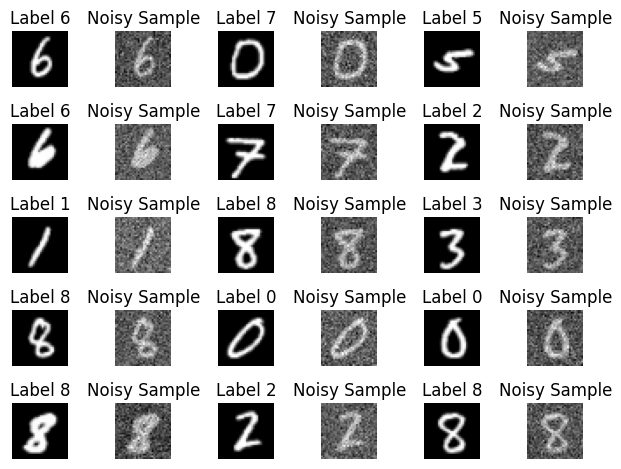

In [94]:
no_samples: int = 5
fig, axis = PLT.subplots(no_samples, 6)   # 3 splits x (clean,noisy) = 6 columns

ex_tr, ex_te, ex_va = enumerate(noisy_train), enumerate(noisy_test), enumerate(noisy_val)
Ex: list = [ex_tr, ex_te, ex_va]

for sample in range(no_samples):
    for index, ex in enumerate(Ex):
        _, (clean_sample, noisy_sample, label) = next(ex)

        col = 2 * index  # <- each split gets two dedicated columns

        # fig.suptitle("")
        axis[sample, col].imshow(clean_sample[0].reshape(32, 32), cmap="gray")
        axis[sample, col].set_title(f"Label {label[0]}")
        axis[sample, col].axis("off")

        axis[sample, col + 1].imshow(noisy_sample[0].reshape(32, 32), cmap="gray")
        axis[sample, col + 1].set_title("Noisy Sample")
        axis[sample, col + 1].axis("off")

PLT.tight_layout()

# Model

## Building the model and helpers (e.g., mini-pipeline)

### mini-pipeline

In [95]:
#TODO - Check further with A.I. to make sure the correspondence between clean-noisy-label images is not altered/lost
#TODO - Do we really need to flatten the clear image as well?
# 1. Flattening the image
# 2. Normalize the image
# 3. Impose a specific image type

def flattener(data:tuple):
    f = nn.Flatten(start_dim=0)
    flattened = [f(item) if isinstance(item, torch.Tensor) else item for item in data[:-1]]
    return tuple(flattened) + (data[-1],)
    
basisc_transf = v2.Compose([
    # transforms.ToTensor(), <- Data is of tensor nature by definition
    # v2.Normalize(mean=[0.5],std=[0.5]),
    flattener
])

### model

In [96]:
#TODO Document all of the function bellow if time allows;

"""
The current models holds ReLu as non-linear activation units.
The network should be a class and its constructor `__init__` should accept an argument defining the width of the network (e.g., layer sizes) - Done

e.g., YourClassName([32**2, 24**2, 16**2, 32**2]) - Done
- 32^2 inputs (one image at a time); - Done
- two hidden layers 24^2 and 16^2; - Done
- 32^2 outputs(the reconstruction of the image) - Done
"""

class BasicFCN(nn.Module):
    def __init__(self, width:list, activation:list):
        super().__init__() # Calling in the constructor of the inhereted class `nn.Module`
        self.width = width
        hid_actv_function = getattr(nn, activation[0])
        final_actv_function = getattr(nn, activation[1])

        # ...start building the network within the constructor 
        self.fcn_input = nn.Linear(in_features=width[0], out_features=width[1], bias=True)
        self.btcnorm1 = nn.BatchNorm1d(width[1])
        self.activation1 = hid_actv_function(0.01)
        self.fcn_hidlay1 = nn.Linear(in_features=width[1], out_features=width[2], bias=True)
        self.btcnorm2 = nn.BatchNorm1d(width[2])
        self.activation2 = hid_actv_function(0.01)
        self.fcn_hidlay2 = nn.Linear(in_features=width[2], out_features=width[3], bias=True)
        self.btcnorm3 = nn.BatchNorm1d(width[3])
        self.activation3 = hid_actv_function(0.01)
        self.fcn_hidlay3 = nn.Linear(in_features=width[3], out_features=width[4], bias=True)
        self.activation4 = hid_actv_function(0.01)
        self.btcnorm4 = nn.BatchNorm1d(width[4])
        self.fcn_hidlay4 = nn.Linear(in_features=width[4], out_features=width[5], bias=True)
        self.btcnorm5 = nn.BatchNorm1d(width[5])
        self.activation5 = hid_actv_function(0.01)
        self.fcn_hidlay5 = nn.Linear(in_features=width[5], out_features=width[6], bias=True)
        self.activation6 = final_actv_function()
  
    def forward(self, x):
        x = self.activation1(self.btcnorm1(self.fcn_input(x)))
        x = self.activation2(self.btcnorm2(self.fcn_hidlay1(x)))
        x = self.activation3(self.btcnorm3(self.fcn_hidlay2(x)))
        x = self.activation4(self.btcnorm4(self.fcn_hidlay3(x)))
        x = self.activation5(self.btcnorm5(self.fcn_hidlay4(x)))
    
        # The Output "Head"
        x = self.fcn_hidlay5(x) 
        x = self.activation6(x) 

        return x

## Training Loop
Loading data, executing sanity check to see how the model handles only one sample and proceed to serious training.

In [ ]:
# 1. Loading data
loc:str = r"/DataSets"
batch_size:int = 64 # Roughly 70k samples;
train, test, val = create_dataloaders(data_loc=loc, batch_size=batch_size, transform=basisc_transf)
activation = [hidd_activation, final_activation]

# Debug Statement 1
# sample_cl, sample_ns = next(enumerate(train))[1][0], next(enumerate(train))[1][0]
# print(torch.max(sample_cl), torch.min(sample_ns))
# 2. Equipping M.L. utils (e.g., define criterion and optimizer); 
#TODO- Code the folders creation for both, visuals and weights within the class;
#TODO- Don't forget to initialize the parser;

model = BasicFCN(activation=activation, width=width)
optimizer = SGD(params=model.parameters(), lr=0.01) # optimizer defined outside of the training loop
# optimizer = AdamW(params=model.parameters(), lr=0.0005)
loss = nn.MSELoss()
model_label:str = 'high-capacity'
if model_label != None and ('weights' in os.listdir()) == False:
    os.makedirs('weights')
    if (model_label in os.listdir('weights')) == False:
        os.makedirs(f'weights\{model_label}')

# 3. Training & Validation kick-off
# 3.1 Creating history-holder containers
loss_container_train, loss_container_te = [], []
for epoch in range(epochs):
    _loss_per_epoch_tr:float = 0.0
    _loss_per_epoch_te:float = 0.0
    #TODO Optimize the looping mechanism for faster iteration;

    # 3.2 Training kicks off
    model.train()
    for cl, ns, label in train:
        optimizer.zero_grad()
        output = model(ns)
        # 3.3 Quantifying the quality of the output; Backpropagate; Optimizer step
        _loss_tr = loss(output,cl) # Compare the batch of recon against the batch with clear
        _loss_tr.backward()
        optimizer.step()
        # 3.4 Keep track of performance
        _loss_per_epoch_tr+=_loss_tr.item()

    loss_container_train.append(_loss_per_epoch_tr/len(train))
    # 4. Testing kicks off
    model.eval()
    with torch.no_grad():
        for cl, ns, label in test:
            output = model(ns)
            _loss_te = loss(output, cl)
            _loss_per_epoch_te+=_loss_te.item()
        loss_container_te.append(_loss_per_epoch_te/len(test))

    print("Epoch {} yielded: Train Loss {:.2f} | Test Loss {:.2f} ".format(epoch, loss_container_train[epoch], loss_container_te[epoch]))
    # 5. Ensures the weights are saved one epoch at a time;
    torch.save(model.state_dict(), f'weights\{model_label}\{model_label}model_weights_epoch{epoch}.pth')
    # 6. Ensures the dictionary are saved one epoch at a time;

#TODO - Automatize the saving of your model;
#TODO - Do weight normalization and try to display visuals 
#TODO - Create folder's checkpoints and save weights and performances (e.g. curves)
#TODO - Answer the questions eventually


Epoch 0 yielded: Train Loss 0.55 | Test Loss 0.34 
Epoch 1 yielded: Train Loss 0.28 | Test Loss 0.24 
Epoch 2 yielded: Train Loss 0.21 | Test Loss 0.20 
Epoch 3 yielded: Train Loss 0.18 | Test Loss 0.17 
Epoch 4 yielded: Train Loss 0.16 | Test Loss 0.16 
Epoch 5 yielded: Train Loss 0.15 | Test Loss 0.14 
Epoch 6 yielded: Train Loss 0.14 | Test Loss 0.14 
Epoch 7 yielded: Train Loss 0.14 | Test Loss 0.13 
Epoch 8 yielded: Train Loss 0.13 | Test Loss 0.12 
Epoch 9 yielded: Train Loss 0.12 | Test Loss 0.12 
Epoch 10 yielded: Train Loss 0.12 | Test Loss 0.11 
Epoch 11 yielded: Train Loss 0.12 | Test Loss 0.11 
Epoch 12 yielded: Train Loss 0.11 | Test Loss 0.11 
Epoch 13 yielded: Train Loss 0.11 | Test Loss 0.11 
Epoch 14 yielded: Train Loss 0.11 | Test Loss 0.10 
Epoch 15 yielded: Train Loss 0.11 | Test Loss 0.10 
Epoch 16 yielded: Train Loss 0.10 | Test Loss 0.10 
Epoch 17 yielded: Train Loss 0.10 | Test Loss 0.10 
Epoch 18 yielded: Train Loss 0.10 | Test Loss 0.09 
Epoch 19 yielded: Trai

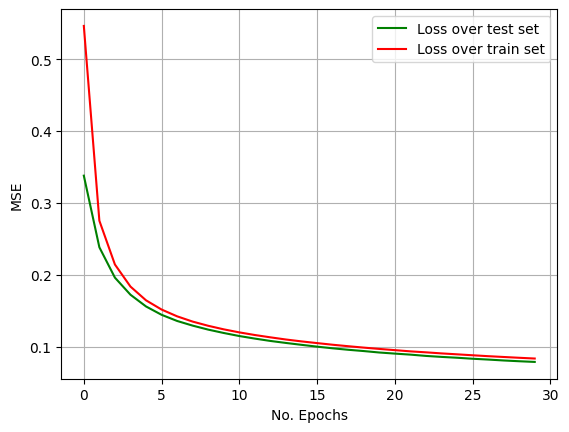

In [98]:
#TODO Transform this into a helper _detach function
# detach_loss_container_te = [item.detach() for item in loss_container_te]
# detach_loss_container_train = [item.detach() for item in loss_container_train]

PLT.plot(loss_container_te, color='green', label='Loss over test set')
PLT.plot(loss_container_train, color='red', label='Loss over train set')
PLT.xlabel("No. Epochs")
PLT.ylabel("MSE")
PLT.grid()
PLT.legend()

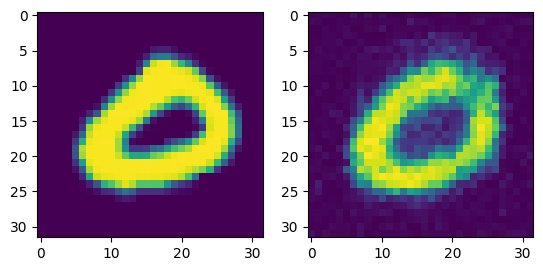

In [105]:
model = BasicFCN(activation=activation, width=width)
model.eval()

label = next(enumerate(val))
_, (cl, ns, label) = label
fig, axis = PLT.subplots(1, 2)
axis[0].imshow(cl[0].reshape(32,32))
model.load_state_dict(torch.load('weights\high-capacity\high-capacitymodel_weights_epoch29.pth'))
output = model(ns[0].reshape(-1,1024))
axis[1].imshow(torch.reshape(output.detach(),(32,32)))

## Training Class

In [ ]:
class Train():
    def __init__(self, model, ):
        pass
    def train(self):
        pass

# Testing

In [14]:
batch_size:int = 64
loc:str = r"/DataSets"
noisy_train, noisy_test, noisy_val = create_dataloaders(data_loc=loc, batch_size=batch_size)

In [152]:
#TODO - Check further with A.I. to make sure the correspondence between clean-noisy-label images is not altered/lost
# 1. Flattening the image
# 2. Normalize the image
# 3. Impose a specific image type

def flattener(data:tuple):
    flattened_items:tuple = ()
    f = nn.Flatten()
    if type(data) is tuple:
        #  Conversion to handle appending
        flattened_items = list(flattened_items)
        for data_batch in data[:2]:
            flattened_items.append(f(data_batch))
    else:
        print("Data type missmatch")

    return tuple(flattened_items) + (data[2],)
    
basic_transofmrations = v2.Compose([
    # transforms.ToTensor(), <- Data is of tensor nature by definition
    flattener
])

for index, (cl, ns, org_label) in enumerate(noisy_train):
    print("BEFORE: cs type: {} and shape {}\nns type: {} and shape {}\nlabel {}".format(type(cl), cl.size(), type(ns), ns.size(), type(label)))
    data = basic_transofmrations((cl, ns, org_label))
    cl, ns, label = data[0], data[1], data[2]
    print("AFTER: cs type: {} and shape {}\nns type: {} and shape {}\nlabel {}".format(type(data), cl.size(), type(ns), ns.size(), type(label)))
    assert torch.equal(org_label, label), "The data pipeline messed up the correspondence"
    print("Everything is fine")
    if index ==3:
        break
 

BEFORE: cs type: <class 'torch.Tensor'> and shape torch.Size([64, 1, 32, 32])
ns type: <class 'torch.Tensor'> and shape torch.Size([64, 1, 32, 32])
label <class 'torch.Tensor'>
AFTER: cs type: <class 'tuple'> and shape torch.Size([64, 1024])
ns type: <class 'torch.Tensor'> and shape torch.Size([64, 1024])
label <class 'torch.Tensor'>
Everything is fine
BEFORE: cs type: <class 'torch.Tensor'> and shape torch.Size([64, 1, 32, 32])
ns type: <class 'torch.Tensor'> and shape torch.Size([64, 1, 32, 32])
label <class 'torch.Tensor'>
AFTER: cs type: <class 'tuple'> and shape torch.Size([64, 1024])
ns type: <class 'torch.Tensor'> and shape torch.Size([64, 1024])
label <class 'torch.Tensor'>
Everything is fine
BEFORE: cs type: <class 'torch.Tensor'> and shape torch.Size([64, 1, 32, 32])
ns type: <class 'torch.Tensor'> and shape torch.Size([64, 1, 32, 32])
label <class 'torch.Tensor'>
AFTER: cs type: <class 'tuple'> and shape torch.Size([64, 1024])
ns type: <class 'torch.Tensor'> and shape torch.

In [5]:
# Sanity checks 
print(len(noisy_train))
print(len(noisy_test))
print(len(noisy_val))

938
157
157


In [ ]:
# # i. Sanity check
# # Commented out. If test is required erase the comments from bellow:
# cl, ns, label = preprocessed_data[0], preprocessed_data[1], preprocessed_data[2]
# cl_sample, ns_sample, label_sample = cl[0], ns[0], label[0]
# model = BasicFCN(activation=activation, width=width)
# model.train()
# output = model.forward(x=ns_sample)
# fig, axis = PLT.subplots(1, 2, figsize=(10,6))
# axis[0].imshow(torch.reshape(output.detach(),(32,32)))
# axis[1].imshow(torch.reshape(cl_sample,(32,32)))
